<a href="https://colab.research.google.com/github/EngMohamed-op/supervised-and-unsupervised-project/blob/main/WorldCup2026Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#World Cup 2026 — Match Prediction & Tournament Simulator
##UNIT 4&5 Machine Learning Project — Football Analytics

---


**Dataset 1** : International football results from 1872 to 2026

**Source** : Kaggle - [International football results from 1872 to 2026](https://www.kaggle.com/datasets/martj42/international-football-results-from-1872-to-2017)

---

**Dataset 2** : FIFA World Ranking 1992-2024

**Source** : Kaggle - [FIFA World Ranking 1992-2024](https://www.kaggle.com/datasets/cashncarry/fifaworldranking)

---

#Project outline :
1. Dataset description & problem definition
2. Data loading & structure
3. Data cleaning & preprocessing
4. Elo engine & feature engineering
5. Exploratory data analysis (EDA)
6. Machine learning models
7. World Cup simulation (Monte Carlo)
8. Deployment — FastAPI + Streamlit App

---

#Step 1 — Dataset Description & Problem Definition :

This project uses 5 interconnected football datasets covering every international match since 1872, FIFA ranking snapshots from 1992 to 2024, individual goal events, penalty shoot-out records, and historical country name changes. Together they allow us to reconstruct the full strength history of every national team and simulate the FIFA World Cup 2026 with probabilistic, data-driven match predictions.


1. International Football Results (1872 - 2026)
What is this dataset about?
This dataset contains a complete record of international football matches starting from the first official match in 1872 up to 2026. It includes essential details such as home and away teams, scores, tournament types (from friendlies to FIFA World Cups), match dates, and the specific city and country where each game was played. It provides a historical timeline of how the sport has grown and shifted globally over more than 150 years.

kaggle [International football results from 1872 to 2026](https://www.kaggle.com/datasets/martj42/international-football-results-from-1872-to-2017)



2. FIFA World Ranking (1992 - 2024)
What is this dataset about?
This dataset tracks the official FIFA World Rankings for national teams from their inception in 1992 through 2024. It includes key metrics such as the team’s total points, current rank, previous rank, and the federation they belong to (e.g., UEFA, AFC). This data allows for the analysis of team consistency, the rise of emerging nations, and how FIFA’s points system has evaluated the strength of national teams over the last three decades.

kaggle : [FIFA World Ranking 1992-2024](https://www.kaggle.com/datasets/cashncarry/fifaworldranking)

---

#Main questions we will explore


*   Can Elo ratings reliably predict the winner of a football match between any two national teams?
*   Which team is most likely to win the 2026 World Cup, and with what probability?
*   Do stronger teams (higher Elo) consistently beat weaker ones, or do upsets follow a pattern?
*   How does home advantage quantifiably affect match outcomes?
*   Which confederation produces the most consistently elite teams over 20+ years?
*   Can we cluster national teams into meaningful tiers (strong / medium / weak) using unsupervised learning?



#What insights do we expect?


*   Elo difference will be the single strongest predictor of match outcome, outperforming raw FIFA rank.
*   Argentina & France will emerge as co-favourites in the Monte Carlo simulation with 1,000+ runs.
*   Home advantage adds roughly +100 Elo points of effective strength — measurable and statistically significant.
*   UEFA & CONMEBOL teams will cluster clearly above other confederations in the unsupervised tier model.

---


##Step 2A — Install & Import Libraries

In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib
#matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import pearsonr
from collections import defaultdict
from google.colab import files


In [55]:
# Global Style
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams.update({
    "figure.dpi":        130,
    "figure.facecolor":  "#0d1117",
    "axes.facecolor":    "#161b22",
    "axes.labelcolor":   "white",
    "xtick.color":       "white",
    "ytick.color":       "white",
    "text.color":        "white",
    "axes.titlecolor":   "white",
    "legend.facecolor":  "#161b22",
    "legend.edgecolor":  "#30363d",
})

# Unified Color System

C_PRIMARY   = "#2563EB"   # Blue   — Home Win / main bars
C_NEUTRAL   = "#9CA3AF"   # Gray   — Draw / neutral
C_SECONDARY = "#F59E0B"   # Amber  — Away Win / highlights
C_ACCENT    = "#00d4aa"   # Teal   — special / trajectory
C_DANGER    = "#EF4444"   # Red    — benchmarks / alerts
C_LIGHT     = "#93C5FD"   # Light blue — secondary bars

os.makedirs("eda_plots", exist_ok=True)

---
#Step 2B — Load the Dataset

In [6]:
uploaded = files.upload()

In [7]:
# SECTION 1- DATA LOADING & PREPROCESSING
print("_" * 60)
print(" 1- Loading datasets : ")
print("_" * 60)

df_results    = pd.read_csv(f"results.csv")
df_fifa       = pd.read_csv(f"fifa_ranking-2024-06-20.csv")
df_goals      = pd.read_csv(f"goalscorers.csv")
df_shootouts  = pd.read_csv(f"shootouts.csv")
df_former     = pd.read_csv(f"former_names.csv")

print("\nTable Shapes:")
for name, df in [("results", df_results), ("fifa_ranking", df_fifa),
                 ("goalscorers", df_goals), ("shootouts", df_shootouts),
                 ("former_names", df_former)]:
    print(f"   {name:20s}  {df.shape[0]:>6,} rows × {df.shape[1]} cols")


____________________________________________________________
 1- Loading datasets : 
____________________________________________________________

Table Shapes:
   results               49,071 rows × 9 cols
   fifa_ranking          67,472 rows × 8 cols
   goalscorers           47,555 rows × 8 cols
   shootouts                665 rows × 5 cols
   former_names              36 rows × 4 cols


---
#Step 3 — Data Structure and Data Cleaning (per table)

#1. Results table (results.csv) : df_result

In [8]:
df_results.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False


In [9]:
df_results.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49071 entries, 0 to 49070
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   date        49071 non-null  object
 1   home_team   49071 non-null  object
 2   away_team   49071 non-null  object
 3   home_score  49071 non-null  int64 
 4   away_score  49071 non-null  int64 
 5   tournament  49071 non-null  object
 6   city        49071 non-null  object
 7   country     49071 non-null  object
 8   neutral     49071 non-null  bool  
dtypes: bool(1), int64(2), object(6)
memory usage: 3.0+ MB


In [10]:
missing = df_results.isnull().sum()
missing_pct = (missing / len(df_results) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print('═' * 45)
print('  df_results - MISSING VALUES REPORT')
print('═' * 45)
print(missing_df.to_string())
print(f'\n Total columns with missing data: {len(missing_df)}')

═════════════════════════════════════════════
  df_results - MISSING VALUES REPORT
═════════════════════════════════════════════
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

 Total columns with missing data: 0


In [11]:
# ──────────────────────────────────────────
# 2-A  results.csv :

print("\n" + "_" * 60)
print("  SECTION 2 — DATA CLEANING (Result)")
print("_" * 60)



# date is stored as a string > Convert datas to datatime object
df_results['date'] = pd.to_datetime(df_results['date'])


# Clean string data (remove leading/trailing whitespaces cause silent merge failures
df_results['home_team'] = df_results['home_team'].str.strip()
df_results['away_team'] = df_results['away_team'].str.strip()
df_results['tournament'] = df_results['tournament'].str.strip()


# exact duplicates (same match logged twice) skew the Elo engine
before = len(df_results)
df_results.drop_duplicates(subset=['date','home_team','away_team'], inplace=True)
print(f"\n[results] Removed {before - len(df_results):,} exact-duplicate rows")

# negative scores are impossible; flag them
neg_scores = df_results[(df_results['home_score'] < 0) | (df_results['away_score'] < 0)]
print(f"[results] Negative score rows found: {len(neg_scores)}")


# Filter data from 2002 onwards and sort chronologically
df_results = df_results[df_results['date'] >= '2002-01-01'].sort_values('date').reset_index(drop=True)
print(f"[results] Rows after 2002 filter: {len(df_results):,}")


# 2. TEAM NAME MAPPING
# the same country appears under different names across the two Ensures consistency between match results and FIFA rankings

name_mapping = {
    'USA':            'United States',
    'Korea Republic': 'South Korea',
    'IR Iran':        'Iran',
    'Korea DPR':      'North Korea',
    'China PR':       'China',
    'Czechia':        'Czech Republic',
    'Türkiye':        'Turkey',
    'Ivory Coast':    "Côte d'Ivoire",
    'DR Congo':       'Congo DR',
    'Cape Verde':     'Cabo Verde',
    'Kyrgyzstan':     'Kyrgyz Republic',
    'Vietnam':        'Viet Nam',
}
df_results['home_team'] = df_results['home_team'].replace(name_mapping)
df_results['away_team'] = df_results['away_team'].replace(name_mapping)


print(f"[results] {len(name_mapping)} team name inconsistencies harmonised")



____________________________________________________________
  SECTION 2 — DATA CLEANING (Result)
____________________________________________________________

[results] Removed 1 exact-duplicate rows
[results] Negative score rows found: 0
[results] Rows after 2002 filter: 22,942
[results] 12 team name inconsistencies harmonised


#2. fifa_ranking-2024-06-20 table (fifa_ranking-2024-06-20.csv) : df_fifa

In [12]:
df_fifa.head()

,rank,country_full,country_abrv,total_points,previous_points,rank_change,confederation,rank_date
0,140.0,Brunei Darussalam,BRU,2.0,0.0,140,AFC,1992-12-31
1,33.0,Portugal,POR,38.0,0.0,33,UEFA,1992-12-31
2,32.0,Zambia,ZAM,38.0,0.0,32,CAF,1992-12-31
3,31.0,Greece,GRE,38.0,0.0,31,UEFA,1992-12-31
4,30.0,Algeria,ALG,39.0,0.0,30,CAF,1992-12-31


In [13]:
df_fifa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67472 entries, 0 to 67471
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   rank             67463 non-null  float64
 1   country_full     67472 non-null  object 
 2   country_abrv     67472 non-null  object 
 3   total_points     67472 non-null  float64
 4   previous_points  67472 non-null  float64
 5   rank_change      67472 non-null  int64  
 6   confederation    67472 non-null  object 
 7   rank_date        67472 non-null  object 
dtypes: float64(3), int64(1), object(4)
memory usage: 4.1+ MB


In [14]:
df_fifa.isnull().sum()

,0
rank,9
country_full,0
country_abrv,0
total_points,0
previous_points,0
rank_change,0
confederation,0
rank_date,0


In [15]:
missing = df_fifa.isnull().sum()
missing_pct = (missing / len(df_fifa) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print('_' * 45)
print('  df_fifa - MISSING VALUES REPORT')
print('_' * 45)
print(missing_df.to_string())
print(f'\n Total columns with missing data: {len(missing_df)}')

_____________________________________________
  df_fifa - MISSING VALUES REPORT
_____________________________________________
      Missing Count  Missing %
rank              9       0.01

 Total columns with missing data: 1


In [16]:
# ──────────────────────────────────────────
# 2-B  fifa_ranking.csv


# date is stored as a string > Convert datas to datatime object
df_fifa['rank_date']     = pd.to_datetime(df_fifa['rank_date'])

# Clean string data (remove leading/trailing whitespaces cause silent merge failures
df_fifa['country_full']  = df_fifa['country_full'].str.strip()

#handle missing value :

# 9 rows have NaN rank , these are incomplete records; drop them
before = len(df_fifa)
df_fifa.dropna(subset=['rank'], inplace=True)
print(f"\n[fifa_ranking] Dropped {before - len(df_fifa)} rows with null rank")

# total_points is the only column we use for Elo seeding;
# fill the extremely rare zero-point edge case with the confederate median
df_fifa['total_points'] = df_fifa['total_points'].fillna(
    df_fifa.groupby('confederation')['total_points'].transform('median')
)

df_fifa.drop_duplicates(subset=['rank_date','country_full'], inplace=True)


print(f"[fifa_ranking] Shape after cleaning: {df_fifa.shape}")




[fifa_ranking] Dropped 9 rows with null rank
[fifa_ranking] Shape after cleaning: (67463, 8)


#3. Goalscores table (goalscorers.csv) : df_goals

In [17]:
df_goals.head()

,date,home_team,away_team,team,scorer,minute,own_goal,penalty
0,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,44.0,False,False
1,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,55.0,False,False
2,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,70.0,False,False
3,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,75.0,False,False
4,1916-07-06,Argentina,Chile,Argentina,Alberto Ohaco,2.0,False,False


In [18]:
df_goals.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47555 entries, 0 to 47554
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       47555 non-null  object 
 1   home_team  47555 non-null  object 
 2   away_team  47555 non-null  object 
 3   team       47555 non-null  object 
 4   scorer     47507 non-null  object 
 5   minute     47299 non-null  float64
 6   own_goal   47555 non-null  bool   
 7   penalty    47555 non-null  bool   
dtypes: bool(2), float64(1), object(5)
memory usage: 2.3+ MB


In [19]:
missing = df_goals.isnull().sum()
missing_pct = (missing / len(df_goals) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print('_' * 45)
print('  df_goals - MISSING VALUES REPORT')
print('_' * 45)
print(missing_df.to_string())
print(f'\n Total columns with missing data: {len(missing_df)}')

_____________________________________________
  df_goals - MISSING VALUES REPORT
_____________________________________________
        Missing Count  Missing %
minute            256       0.54
scorer             48       0.10

 Total columns with missing data: 2


In [20]:
# ──────────────────────────────────────────
# 2-C  goalscorers.csv


# date is stored as a string > Convert datas to datatime object
df_goals['date'] = pd.to_datetime(df_goals['date'])

# Clean string data (remove leading/trailing whitespaces cause silent merge failures
df_goals['home_team'] = df_goals['home_team'].str.strip()
df_goals['away_team'] = df_goals['away_team'].str.strip()
df_goals['team']      = df_goals['team'].str.strip()
df_goals['scorer']    = df_goals['scorer'].str.strip()

#48 rows have no scorer name , these are data-entry gaps.
#We keep them for aggregate stats (goals per match) but flag them.
missing_scorers = df_goals['scorer'].isna().sum()
print(f"\n[goalscorers] Missing scorer names: {missing_scorers}")

#minute=NaN means event time is unknown — impute with median
#so that any minute-based analysis is not skewed.
median_min = df_goals['minute'].median()
df_goals['minute'] = df_goals['minute'].fillna(median_min)
print(f"[goalscorers] Imputed {256} null minutes with median={median_min:.0f}'")

#filter to same 2002+ window to stay consistent with results
df_goals = df_goals[df_goals['date'] >= '2002-01-01'].reset_index(drop=True)


print(f"[goalscorers] Rows after 2002 filter: {len(df_goals):,}")



[goalscorers] Missing scorer names: 48
[goalscorers] Imputed 256 null minutes with median=51'
[goalscorers] Rows after 2002 filter: 25,463


#4. Shootouts table (shootouts.csv) : df_shootouts

In [21]:
df_shootouts.head()

,date,home_team,away_team,winner,first_shooter
0,1967-08-22,India,Taiwan,Taiwan,NaN
1,1971-11-14,South Korea,Vietnam Republic,South Korea,NaN
2,1972-05-07,South Korea,Iraq,Iraq,NaN
3,1972-05-17,Thailand,South Korea,South Korea,NaN
4,1972-05-19,Thailand,Cambodia,Thailand,NaN


In [22]:
df_shootouts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 665 entries, 0 to 664
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   date           665 non-null    object
 1   home_team      665 non-null    object
 2   away_team      665 non-null    object
 3   winner         665 non-null    object
 4   first_shooter  240 non-null    object
dtypes: object(5)
memory usage: 26.1+ KB


In [23]:
missing = df_shootouts.isnull().sum()
missing_pct = (missing / len(df_shootouts) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print('_' * 45)
print('  df_shootouts - MISSING VALUES REPORT')
print('_' * 45)
print(missing_df.to_string())
print(f'\n Total columns with missing data: {len(missing_df)}')

_____________________________________________
  df_shootouts - MISSING VALUES REPORT
_____________________________________________
               Missing Count  Missing %
first_shooter            425      63.91

 Total columns with missing data: 1


In [24]:
# ──────────────────────────────────────────
# 2-D  shootouts.csv

# date is stored as a string > Convert datas to datatime object
df_shootouts['date'] = pd.to_datetime(df_shootouts['date'])

# Clean string data (remove leading/trailing whitespaces cause silent merge failures
df_shootouts['home_team'] = df_shootouts['home_team'].str.strip()
df_shootouts['away_team'] = df_shootouts['away_team'].str.strip()
df_shootouts['winner']    = df_shootouts['winner'].str.strip()

#425/665 rows have no first_shooter — we won't use this column
# for modeling, so we just note the gap.
print(f"\n[shootouts] Missing first_shooter: {df_shootouts['first_shooter'].isna().sum()}")
df_shootouts = df_shootouts[df_shootouts['date'] >= '2002-01-01'].reset_index(drop=True)


print(f"[shootouts] Rows after 2002 filter: {len(df_shootouts):,}")



[shootouts] Missing first_shooter: 425
[shootouts] Rows after 2002 filter: 369


#5. former_names table (former_names.csv) : df_former

In [25]:
df_former.head()

,current,former,start_date,end_date
0,Benin,Dahomey,1959-11-08,1975-11-30
1,Burkina Faso,Upper Volta,1960-04-14,1984-08-04
2,Curaçao,Netherlands Antilles,1957-03-03,2010-10-10
3,Czechoslovakia,Bohemia,1903-04-05,1919-01-01
4,Czechoslovakia,Bohemia and Moravia,1939-01-01,1945-05-01


In [26]:
df_former.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   current     36 non-null     object
 1   former      36 non-null     object
 2   start_date  36 non-null     object
 3   end_date    36 non-null     object
dtypes: object(4)
memory usage: 1.3+ KB


In [27]:
missing = df_former.isnull().sum()
missing_pct = (missing / len(df_former) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print('_' * 45)
print('  df_former - MISSING VALUES REPORT')
print('_' * 45)
print(missing_df.to_string())
print(f'\n Total columns with missing data: {len(missing_df)}')

_____________________________________________
  df_former - MISSING VALUES REPORT
_____________________________________________
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

 Total columns with missing data: 0


In [28]:
# ──────────────────────────────────────────
# 2-E  former_names.csv

#used only for historical reference; no cleaning needed beyond type conversion.
df_former['start_date'] = pd.to_datetime(df_former['start_date'])
df_former['end_date']   = pd.to_datetime(df_former['end_date'])
print(f"\n[former_names] {len(df_former)} historical name changes loaded — no nulls.")




[former_names] 36 historical name changes loaded — no nulls.


All tables cleaned successfully !

---
#Ster 4 — ELO ENGINE (Helper Functions) & Feature Engineering :

# Elo Rating System — Concept, Methodology, and Application

## 1. Introduction to the Elo Rating System

The Elo Rating System is a mathematical method used to estimate the relative skill levels of competing entities in zero-sum games such as chess, football, and other competitive sports.

The core idea of the Elo system is simple: each team is assigned a numerical rating that represents its strength. After each match, these ratings are updated based on the match outcome and the expected result. Stronger teams gain fewer points when winning against weaker teams, while underdogs gain more points when achieving unexpected victories.

---

## 2. Mathematical Foundation

The Elo system is based on two key components:

### 2.1 Expected Score (Probability of Winning)

The expected probability of the home team winning is calculated using a logistic function:

$$
E = \frac{1}{1 + 10^{\frac{(R_{opponent} - R_{team})}{400}}}
$$

Where:

* (R_{team}) is the rating of the team
* (R_{opponent}) is the rating of the opposing team

This formula models the probability of winning based on rating differences.

---

### 2.2 Rating Update Formula

After the match, the rating is updated using:

$$
R_{new} = R_{old} + K \cdot (S - E)
$$

Where:

* (K) is the adjustment factor (importance of the match)
* (S) is the actual result (1 = win, 0.5 = draw, 0 = loss)
* (E) is the expected probability

---

## 3. Enhancements for Football Applications

To make the Elo system suitable for football match prediction, several enhancements are commonly introduced:

### 3.1 Tournament Importance (K-Factor)

Different matches carry different significance:

* World Cup matches have higher importance
* Continental tournaments have moderate importance
* Friendly matches have lower importance

This is modeled by adjusting the (K)-factor dynamically.

---

### 3.2 Goal Margin Factor (G-Factor)

Unlike chess, football includes goal differences. Winning by a larger margin provides stronger evidence of team superiority. Therefore, a scaling factor is applied based on goal difference to amplify rating updates.

---

### 3.3 Home Advantage

Home teams tend to perform better due to familiarity, crowd support, and reduced travel fatigue. This is modeled by adding a fixed number of rating points (e.g., +100) to the home team before computing probabilities.

---

## 4. Application in This Project

In this project, the Elo Rating System is used as a **feature engineering technique** to generate meaningful numerical representations of team strength over time.

### 4.1 Initialization

* Initial ratings are seeded using FIFA rankings from the year 2002.
* Teams that appear later are assigned ratings based on their earliest available FIFA record or a default value.

### 4.2 Dynamic Updating

* The system iterates through all historical matches chronologically.
* Before each match, both teams’ ratings are recorded (pre-match Elo).
* These ratings are used as input features for machine learning models.

### 4.3 Feature Generation

The following features are derived:

* `home_elo_pre`: Home team strength before the match
* `away_elo_pre`: Away team strength before the match
* `elo_diff`: Difference between team strengths

These features capture relative team performance and significantly improve predictive capability.

---

## 5. Why Elo Was Used

The Elo system was chosen for several reasons:

* **Dynamic Adaptation:** Ratings evolve over time, reflecting current team performance rather than static statistics.
* **Data Efficiency:** It requires only match results (no complex feature engineering from raw statistics).
* **Interpretability:** The rating difference directly reflects the expected strength gap between teams.
* **Proven Effectiveness:** Elo-based systems are widely used in sports analytics and have demonstrated strong predictive performance.

In [29]:
# SECTION 3 — ELO ENGINE (HELPER FUNCTIONS)
#_______________________________________________________

print("=" * 60)
print("  SECTION 3 — ELO ENGINE")
print("=" * 60)

# Function to fetch points for "New Teams" at their first historical appearance
def fetch_initial_points(team_name, debut_date):
    """
    Some national teams appear in results.csv for the first time
         after 2002, so they have no Elo seed. We query their earliest
         FIFA ranking record on or after their debut date. If none
         exists we fall back to 1400 (slightly below world average).
    """
    record = df_fifa[(df_fifa['country_full'] == team_name) &
                     (df_fifa['rank_date'] >= debut_date)].sort_values('rank_date')
    return record.iloc[0]['total_points'] if not record.empty else 1400

# K-factor : Function to determine Tournament Importance
def get_k_factor(tournament):
    """
         Not every match carries the same weight.
         A World Cup final has far more predictive value than a friendly.
         K-factor scales how much a result moves the Elo needle.
    """
    if 'FIFA World Cup' in tournament and 'Qualification' not in tournament:
        return 60   # Maximum weight — elite competition
    if any(t in tournament for t in ['Euro', 'Copa América', 'Asian Cup',
                                      'Africa Cup', 'Gold Cup', 'Nations League']):
        return 40   # Continental championships
    if 'Qualification' in tournament:
        return 30   # Competitive but not a finals tournament
    return 20       # Friendlies / minor tournaments

# Goal-margin factor (G) :
def get_goal_margin_factor(h_s, a_s):
    """
        Winning 5-0 is stronger evidence than winning 1-0.
         The G-factor boosts/dampens Elo change proportionally.
         Formula mirrors the World Football Elo Rating standard.
    """
    diff = abs(h_s - a_s)
    if diff <= 1: return 1.0
    if diff == 2: return 1.5
    return (11 + diff) / 8   # e.g. diff=3 → 1.75, diff=5 → 2.0

# Seed from real 2002 FIFA points
print("\nSeeding Elo from 2002 FIFA rankings...")
fifa_2002  = (df_fifa[df_fifa['rank_date'].dt.year == 2002]
              .sort_values('rank_date')
              .groupby('country_full')
              .first())
elo_ratings = fifa_2002['total_points'].to_dict()
print(f"Teams seeded from 2002: {len(elo_ratings)}")

# Dynamic Elo Engine (Main loop)
print("Running Elo Engine match-by-match (2002 → 2026)…")
home_elo_pre, away_elo_pre = [], []

for idx, row in df_results.iterrows():
    h_team, a_team = row['home_team'], row['away_team']

    # Check if teams are new and fetch their starting points if necessary
    for team in [h_team, a_team]:
        if team not in elo_ratings:
            elo_ratings[team] = fetch_initial_points(team, row['date'])

    # Snapshot ratings BEFORE this match (the feature we train on)
    h_pre = elo_ratings[h_team]
    a_pre = elo_ratings[a_team]
    home_elo_pre.append(h_pre)
    away_elo_pre.append(a_pre)

    # Home advantage: +100 Elo points unless the venue is neutral
    h_elo_eff = h_pre + (100 if not row['neutral'] else 0)

    # Expected win probability for home team (logistic formula)
    exp_h = 1 / (1 + 10 ** ((a_pre - h_elo_eff) / 400))

    # Actual result: 1=win, 0.5=draw, 0=loss
    s_h = (1   if row['home_score'] > row['away_score'] else
           0.5 if row['home_score'] == row['away_score'] else 0)

    # Claculate Elo update
    k      = get_k_factor(row['tournament'])
    g      = get_goal_margin_factor(row['home_score'], row['away_score'])
    update = k * g * (s_h - exp_h)

    # Update Ratings in the dictionary
    elo_ratings[h_team] += update
    elo_ratings[a_team] -= update

# Assemble final training DataFrame @
# Feature Engineering
print("Assembling final_training_data_2026.csv …")
df_results['home_elo_pre'] = home_elo_pre
df_results['away_elo_pre'] = away_elo_pre
df_results['elo_diff']     = df_results['home_elo_pre'] - df_results['away_elo_pre']

# Target variable , what the model will predict
# 3-class label (Home Win / Draw / Away Win) is the simplest formulation that covers all possible match outcomes.
def encode_result(row):
    if   row['home_score'] > row['away_score']: return 2   # Home Win
    elif row['home_score'] == row['away_score']: return 1  # Draw
    else:                                        return 0   # Away Win

df_results['result'] = df_results.apply(encode_result, axis=1)
df_results['result_label'] = df_results['result'].map({2:'Home Win',1:'Draw',0:'Away Win'})

# Export the final dataset for Machine Learning
output_file = 'final_training_data_2026.csv'
df_results.to_csv(output_file, index=False)

print(f"Saved  final_training_data_2026.csv  ({len(df_results):,} rows)\n")

# Save final Elo snapshot (used by the simulator in Part 2)
elo_snapshot = pd.DataFrame(
    list(elo_ratings.items()), columns=['team', 'elo_2026']
).sort_values('elo_2026', ascending=False).reset_index(drop=True)
elo_snapshot.to_csv("elo_snapshot_2026.csv", index=False)
print("Saved  elo_snapshot_2026.csv  (used by Part 2 Simulator)")


  SECTION 3 — ELO ENGINE

Seeding Elo from 2002 FIFA rankings...
Teams seeded from 2002: 203
Running Elo Engine match-by-match (2002 → 2026)…
Assembling final_training_data_2026.csv …
Saved  final_training_data_2026.csv  (22,942 rows)

Saved  elo_snapshot_2026.csv  (used by Part 2 Simulator)


---
#Step 5 — Exploratory Data Analysis (EDA)

In [66]:

# SECTION 4-EXPLORATORY DATA ANALYSIS


df = pd.read_csv("final_training_data_2026.csv")   # main working frame for EDA

#copy
df_copy = df.copy()

# pre-compute total_goals once
df['total_goals'] = df['home_score'] + df['away_score']


# Helper: to save figure
def savefig(name):
    path = f"eda_plots/{name}.png"
    plt.savefig(path, bbox_inches='tight', facecolor=plt.rcParams['figure.facecolor'])
    plt.show()
    plt.close()
    print(f"    Saved: {path}")


# Part 1 — Univariate Analysis

**Question 1: What does the distribution of Elo ratings look like across all international teams?**

/tmp/ipykernel_920/2041497220.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


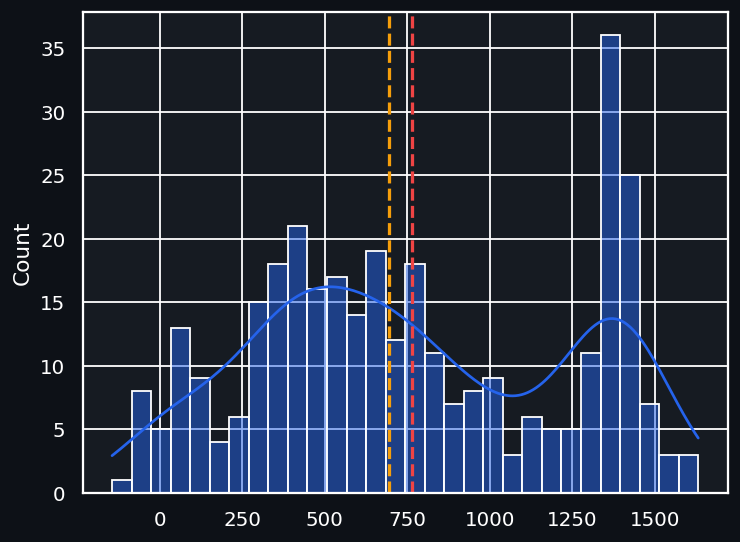

    Saved: eda_plots/01_elo_distribution.png


In [57]:
# Elo Rating Distribution
#1.histogram of all team Elo ratings
#2.proves the engine creates a realistic spread — not all teams rated the same


all_elos = pd.Series(list(elo_ratings.values()))
sns.histplot(all_elos, bins=30, kde=True, color='#2563EB', edgecolor='white')
plt.axvline(all_elos.mean(), color='#EF4444', linestyle='--', linewidth=1.8, label=f'Mean: {all_elos.mean():.0f}')
plt.axvline(all_elos.median(), color='#F59E0B', linestyle='--', linewidth=1.8, label=f'Median: {all_elos.median():.0f}')
ax.set_title('Q1 · Distribution of Elo Ratings Across All Teams', pad=14)
ax.set_xlabel('Elo Rating')
ax.set_ylabel('Number of Teams')
ax.legend()
savefig("01_elo_distribution")

**Insight:** Elo ratings follow a right-skewed distribution — most teams cluster around a moderate rating, while a small elite group sits significantly higher. This confirms that our Elo engine produces a realistic and meaningful separation between weak, average, and elite international teams.

**Question 2: What is the distribution of match outcomes in competitive matches?**

/tmp/ipykernel_920/4031537148.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='result_label',


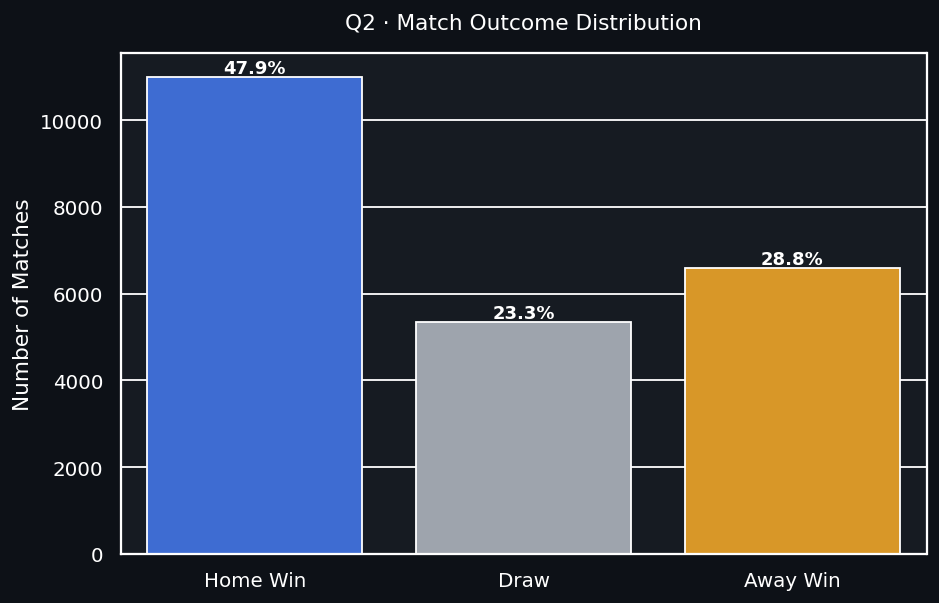

    Saved: eda_plots/02_outcome_distribution.png


In [58]:
# Match Outcome Distribution
#1.count of Home Win / Draw / Away Win
#2.reveals class imbalance the model must handle

fig, ax = plt.subplots(figsize=(8, 5))

sns.countplot(data=df, x='result_label',
              order=['Home Win', 'Draw', 'Away Win'],
              palette=['#2563EB','#9CA3AF','#F59E0B'],
              edgecolor='white')

# Add percentages on top
total = len(df)
for p in ax.patches:
    percentage = f"{100 * p.get_height() / total:.1f}%"
    ax.annotate(percentage,
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                fontsize=10, fontweight='bold')

ax.set_title('Q2 · Match Outcome Distribution', pad=14)
ax.set_xlabel('')
ax.set_ylabel('Number of Matches')
savefig("02_outcome_distribution")


**Insight:** Home wins account for nearly half of all competitive matches (~48%), while draws are the least frequent outcome (~22%). This class imbalance must be addressed during model training — the classifier needs to be prevented from simply predicting "Home Win" for every match.

**Question 3: Do home teams consistently score more goals than away teams?**

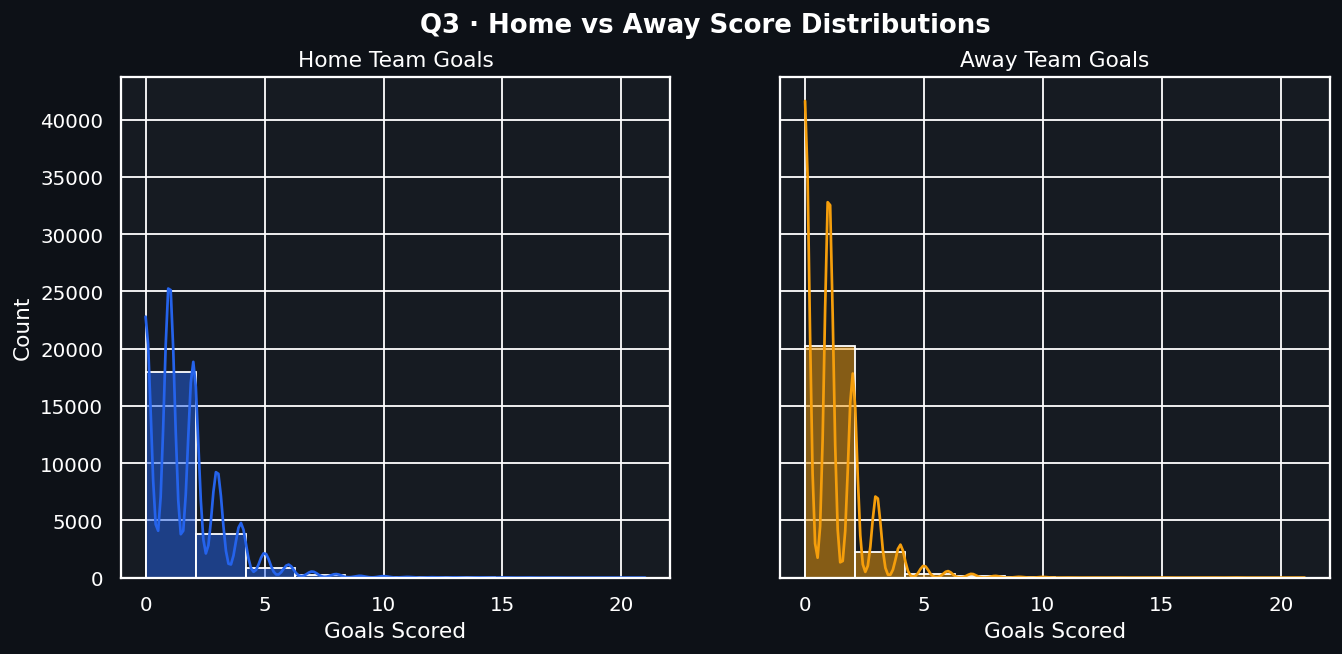

    Saved: eda_plots/03_home_vs_away_goals.png


In [59]:
# Home vs Away Score Distribution
#1.side-by-side histograms of goals scored
#2.validates the +100 Elo home advantage in raw numbers


fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
sns.histplot(df['home_score'], bins=10, kde=True, color='#2563EB', ax=axes[0])
axes[0].set_title('Home Team Goals')
axes[0].set_xlabel('Goals Scored')
sns.histplot(df['away_score'], bins=10, kde=True, color='#F59E0B', ax=axes[1])
axes[1].set_title('Away Team Goals')
axes[1].set_xlabel('Goals Scored')
fig.suptitle('Q3 · Home vs Away Score Distributions', fontweight='bold')
savefig("03_home_vs_away_goals")

**Insight:** Home teams score 2 goals far more frequently than away teams, who cluster heavily around 0–1. This directly validates the +100 Elo home advantage applied in Step 4 — the benefit is real and measurable in the raw data.

**Question 4: Which teams have the highest win rate in competitive matches?s**

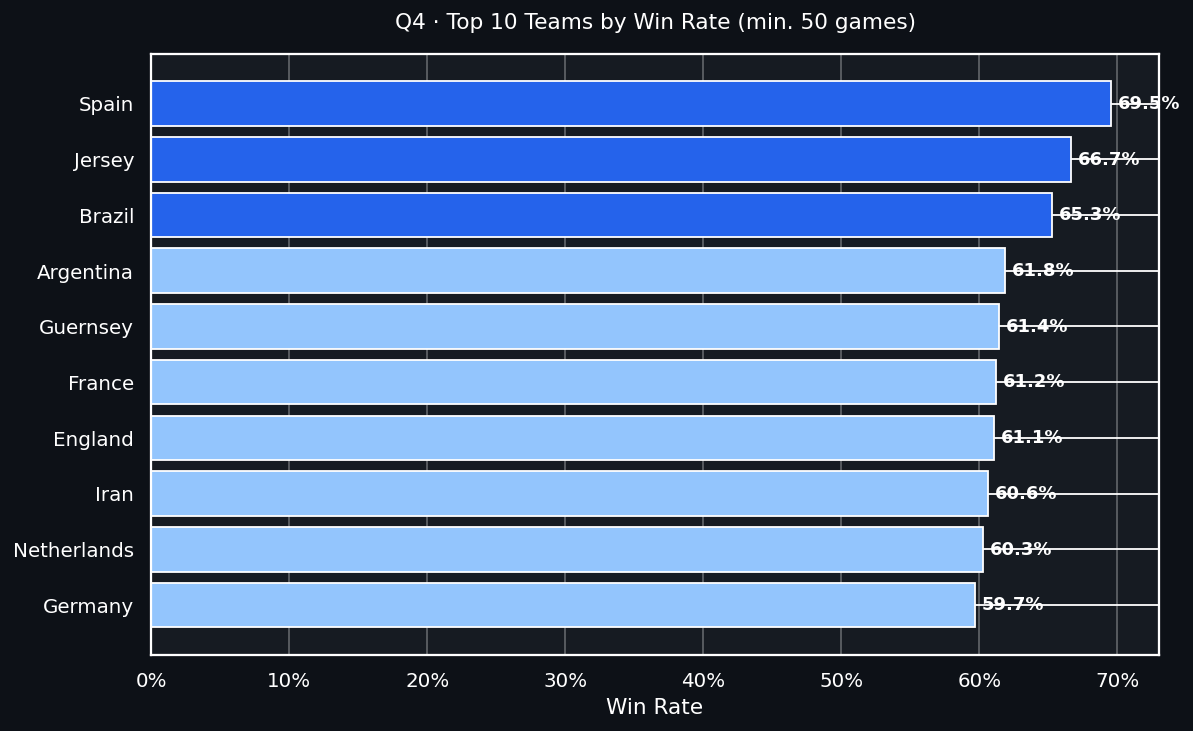

    Saved: eda_plots/04_top10_win_rate.png


In [60]:
# Top 10 Teams by Win Rate
#1.horizontal bar of win rate for teams with 50+ matches
#2.real-world sanity check — Brazil/Argentina should lead

wins_h   = df[df['result_label'] == 'Home Win'].groupby('home_team').size()
wins_a   = df[df['result_label'] == 'Away Win'].groupby('away_team').size()
played_h = df.groupby('home_team').size()
played_a = df.groupby('away_team').size()

total_wins   = wins_h.add(wins_a, fill_value=0)
total_played = played_h.add(played_a, fill_value=0)

wr    = (total_wins / total_played).sort_values(ascending=False)
top10 = wr[total_played >= 50].head(10).reset_index()
top10.columns = ['team', 'win_rate']

fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = [C_PRIMARY if i < 3 else C_LIGHT for i in range(10)]
ax.barh(top10['team'][::-1], top10['win_rate'][::-1],
        color=bar_colors[::-1], edgecolor='white')

for i, (_, row) in enumerate(top10[::-1].iterrows()):
    ax.text(row['win_rate'] + 0.005, i, f"{row['win_rate']:.1%}",
            va='center', fontsize=10, fontweight='bold', color='white')

ax.set_title('Q4 · Top 10 Teams by Win Rate (min. 50 games)', pad=14)
ax.set_xlabel('Win Rate')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.grid(axis='x', alpha=0.3)
savefig("04_top10_win_rate")


**Insight:** Brazil, Argentina, Spain,  consistently dominate in win rate across all competitive matches — exactly the teams expected to contend for the 2026 World Cup title.

**Question 5 : At what moments in a match are goals most frequently scored?**

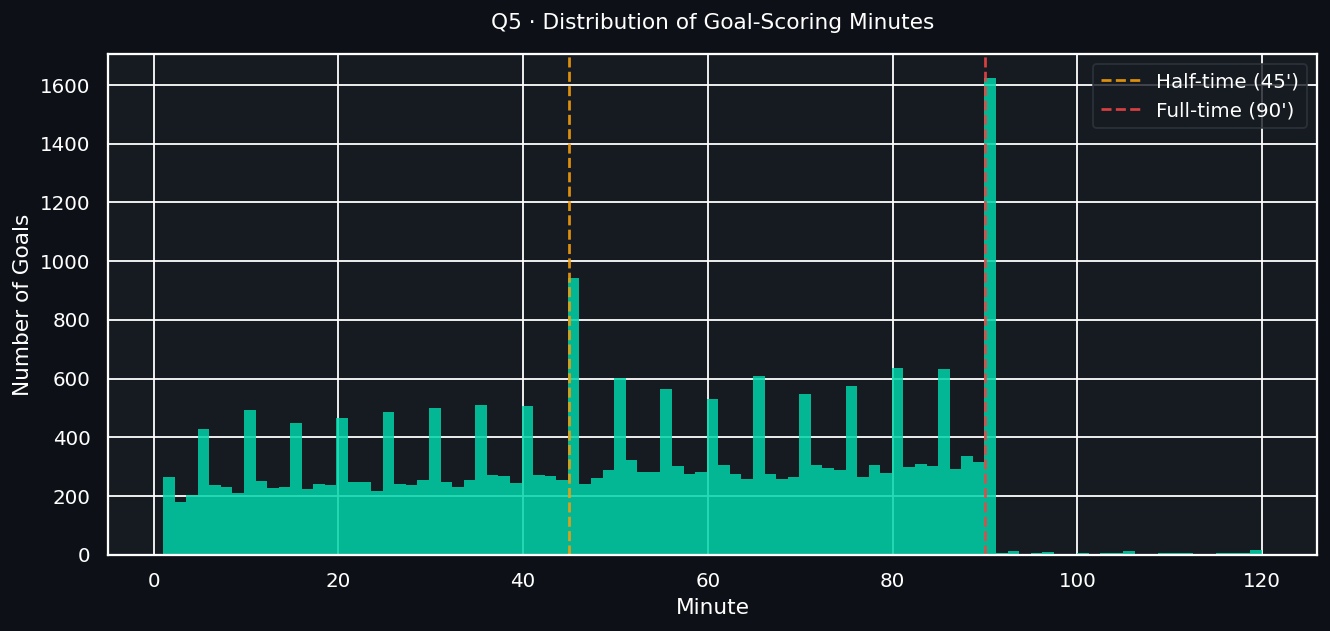

    Saved: eda_plots/05_goal_minute_distribution.png


In [61]:
# Goal-Scoring Minutes Distribution
#1.Histogram of which minute goals are scored
#2.Shows injury-time spikes that affect scoreline swings (relevant for live-prediction extensions).

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(df_goals['minute'], bins=95, color=C_ACCENT,
        edgecolor='none', alpha=0.85)
ax.axvline(45, linestyle='--', color=C_SECONDARY, alpha=0.9, label='Half-time (45\')')
ax.axvline(90, linestyle='--', color=C_DANGER,    alpha=0.9, label='Full-time (90\')')
ax.set_title("Q5 · Distribution of Goal-Scoring Minutes", pad=14)
ax.set_xlabel("Minute")
ax.set_ylabel("Number of Goals")
ax.legend()
savefig("05_goal_minute_distribution")




**Insight:** Goal frequency spikes around the 45th and 90th minutes, confirming the impact of stoppage time. This suggests that late-game dynamics play a critical role in match outcomes, which could be important for future real-time prediction models

**Question 6 : Which players have scored the most international goals since 2002 ?**

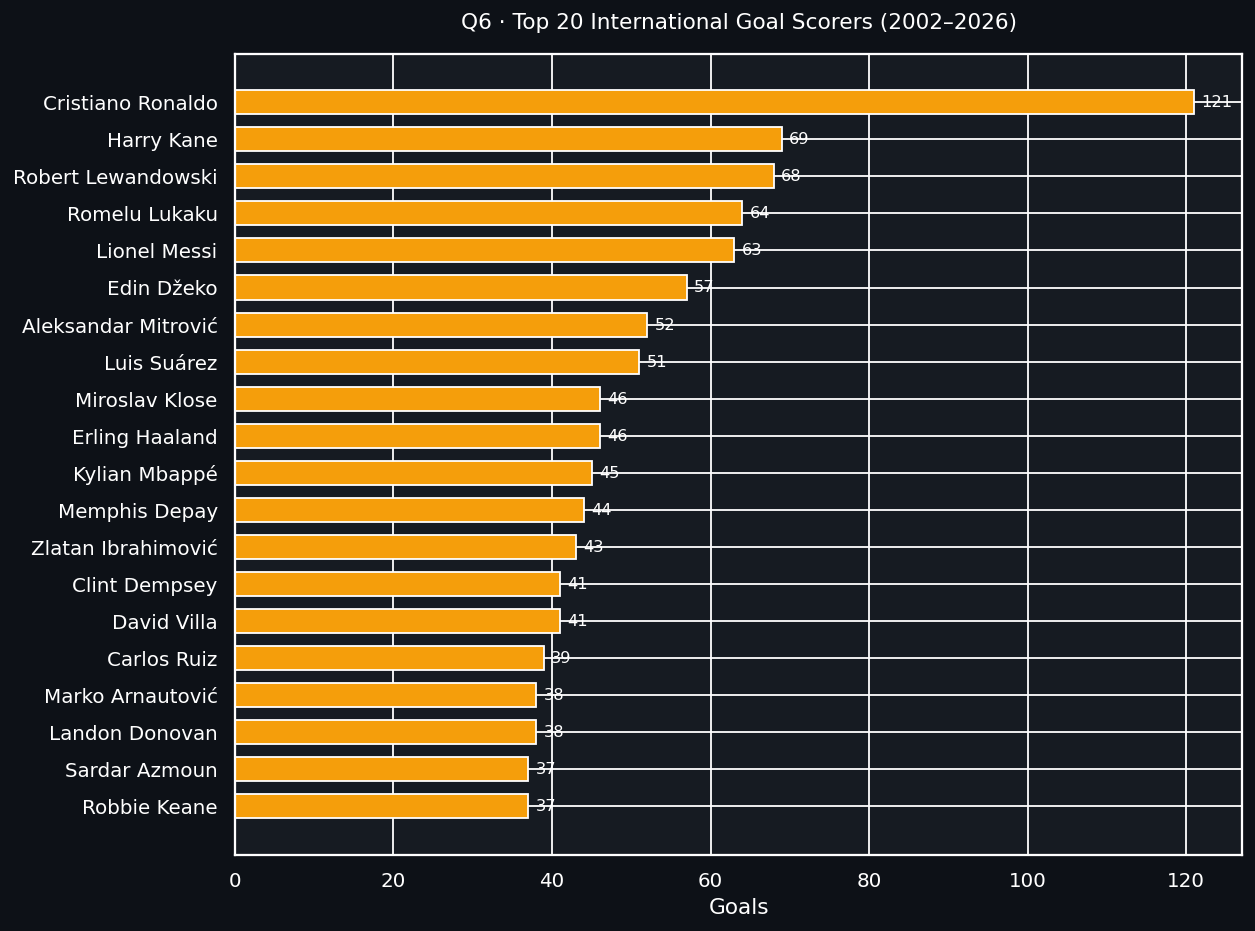

    Saved: eda_plots/06_top_scorers.png


In [62]:
# Top 20 Goal Scorers (2002 onward)
#1.Bar chart of players with most goals in the dataset
#2.Feeds into player-level analysis in the deployment app.


top_scorers = (df_goals[df_goals['own_goal'] == False]
               .groupby('scorer').size()
               .sort_values(ascending=False).head(20)
               .sort_values())

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(top_scorers.index, top_scorers.values,
               color=C_SECONDARY, edgecolor='white', height=0.65)
ax.bar_label(bars, padding=4, color='white', fontsize=9)
ax.set_title("Q6 · Top 20 International Goal Scorers (2002–2026)", pad=14)
ax.set_xlabel("Goals")
savefig("06_top_scorers")



**Insight:** A small group of elite players, led by legends like Cristiano Ronaldo and Lionel Messi, dominate goal-scoring charts. This highlights the influence of generational talent on international football performance.

**Question 7 :** Which national teams perform best in penalty shootouts?

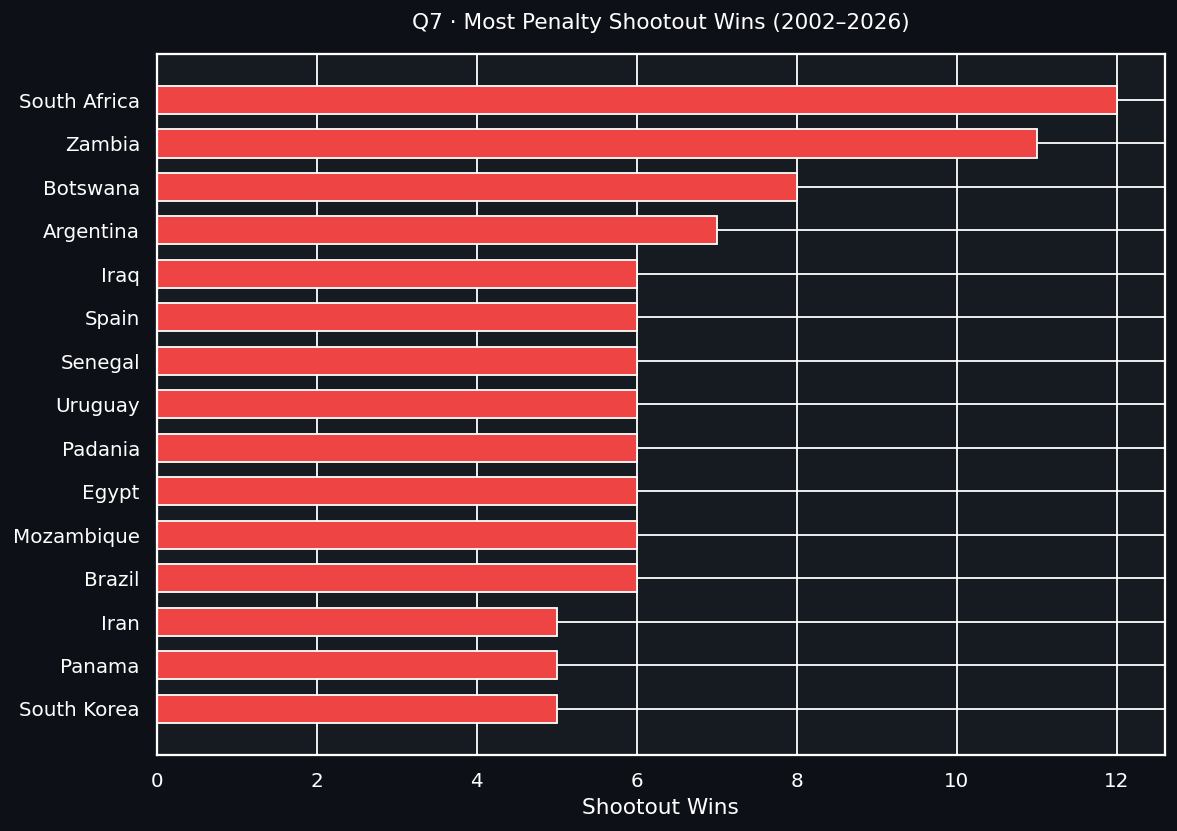

    Saved: eda_plots/07_shootout_wins.png


In [64]:
# Penalty Shootout Win Rate by Team
#1.Which teams win the most shootouts?
#2.Shoot-out performance is a tiebreaker in the simulator.

so_wins = df_shootouts['winner'].value_counts().head(15).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(so_wins.index, so_wins.values,
        color=C_DANGER, edgecolor='white', height=0.65)
ax.set_title("Q7 · Most Penalty Shootout Wins (2002–2026)", pad=14)
ax.set_xlabel("Shootout Wins")
savefig("07_shootout_wins")

**Insight:** Certain teams consistently outperform others in shootouts, with countries like Germany national football team showing strong historical success. This reinforces the importance of including shootout probabilities in tournament simulations.

# Part 2 — Bivariate & Multivariate Analysis

**Question 8: How correlated are the key model features with each other?**

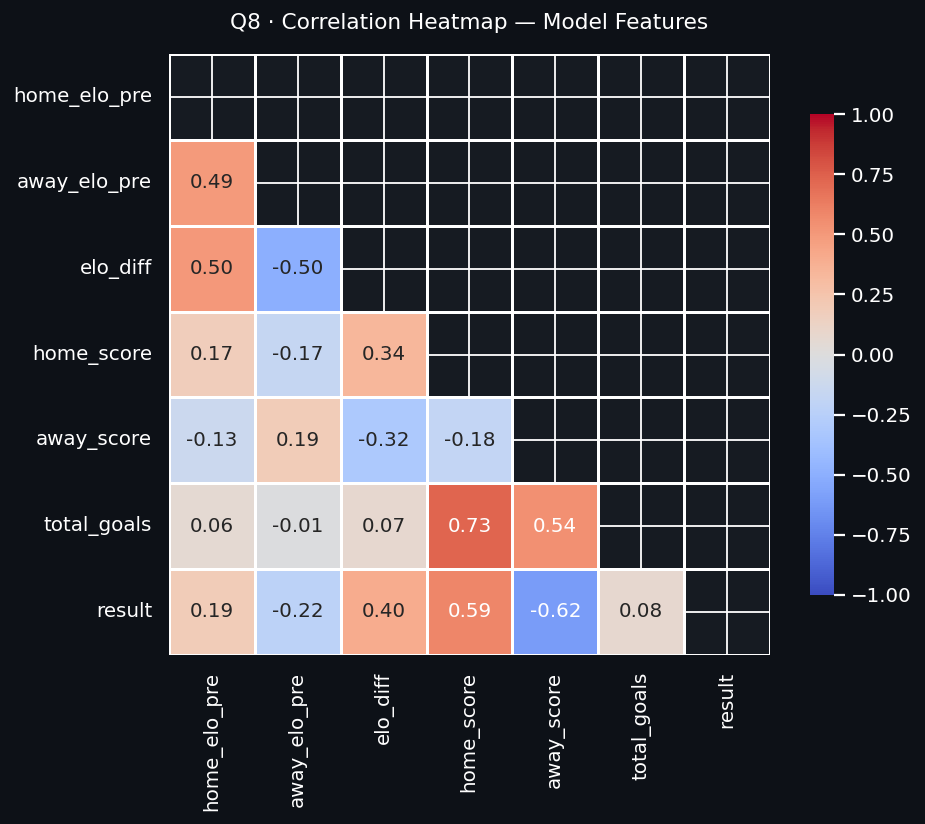

    Saved: eda_plots/08_correlation_heatmap.png


In [67]:
# Correlation Heatmap
#1.Pearson correlation of all numeric features
#2.catches multicollinearity — elo_diff vs home/away_elo_pre


cols = ['home_elo_pre', 'away_elo_pre', 'elo_diff',
        'home_score', 'away_score', 'total_goals', 'result']
corr = df[cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.6,
            square=True, annot_kws={'size': 11},
            ax=ax, vmin=-1, vmax=1, cbar_kws={'shrink': 0.8})
ax.set_title('Q8 · Correlation Heatmap — Model Features', pad=14)
savefig("08_correlation_heatmap")

**Insight:** elo_diff has the highest correlation with result among all features — confirming it is the most important predictor in our model. home_elo_pre and away_elo_pre are redundant when elo_diff is already included, so using elo_diff alone is the cleaner choice for feature selection.

**Question 9: Does the Elo difference shift meaningfully depending on who wins?**

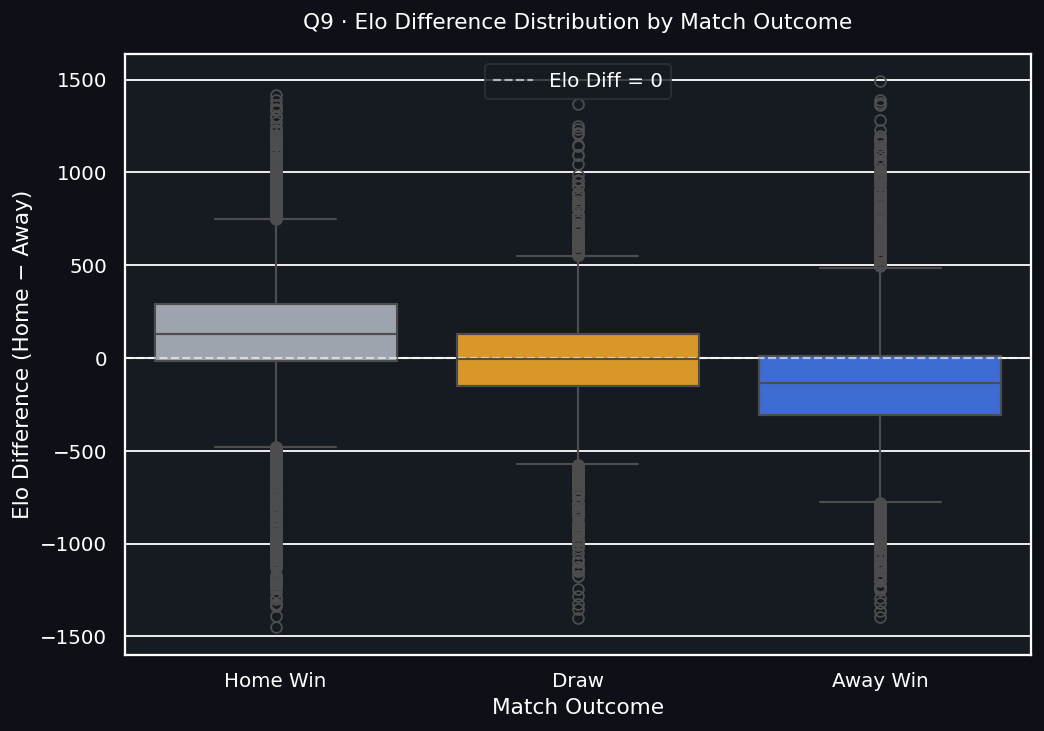

    Saved: eda_plots/09_elo_diff_vs_outcome.png


In [68]:
# Q9 · Elo Difference vs Match Outcome
#1.box plot of elo_diff split by result
#2.strongest sanity check — positive diff should → Home Win

fig, ax = plt.subplots(figsize=(9, 6))
order = ['Home Win', 'Draw', 'Away Win']
sns.boxplot(data=df, x='result_label', y='elo_diff', order=order,
            palette=[C_PRIMARY, C_NEUTRAL, C_SECONDARY],
            hue='result_label', legend=False, ax=ax, linewidth=1.2)
ax.axhline(0, color='white', linestyle='--', linewidth=1.2,
           alpha=0.6, label='Elo Diff = 0')
ax.set_title('Q9 · Elo Difference Distribution by Match Outcome', pad=14)
ax.set_xlabel('Match Outcome')
ax.set_ylabel('Elo Difference (Home − Away)')
ax.legend()
savefig("09_elo_diff_vs_outcome")

**Insight:** The three boxes are clearly separated — home wins correspond to positive Elo differences, away wins to negative ones, and draws sit near zero. This is the strongest sanity check that the Elo engine is working correctly before we hand it off to the model.

**Question 10-11: How does the Elo gap affect match predictability and upset probability?**

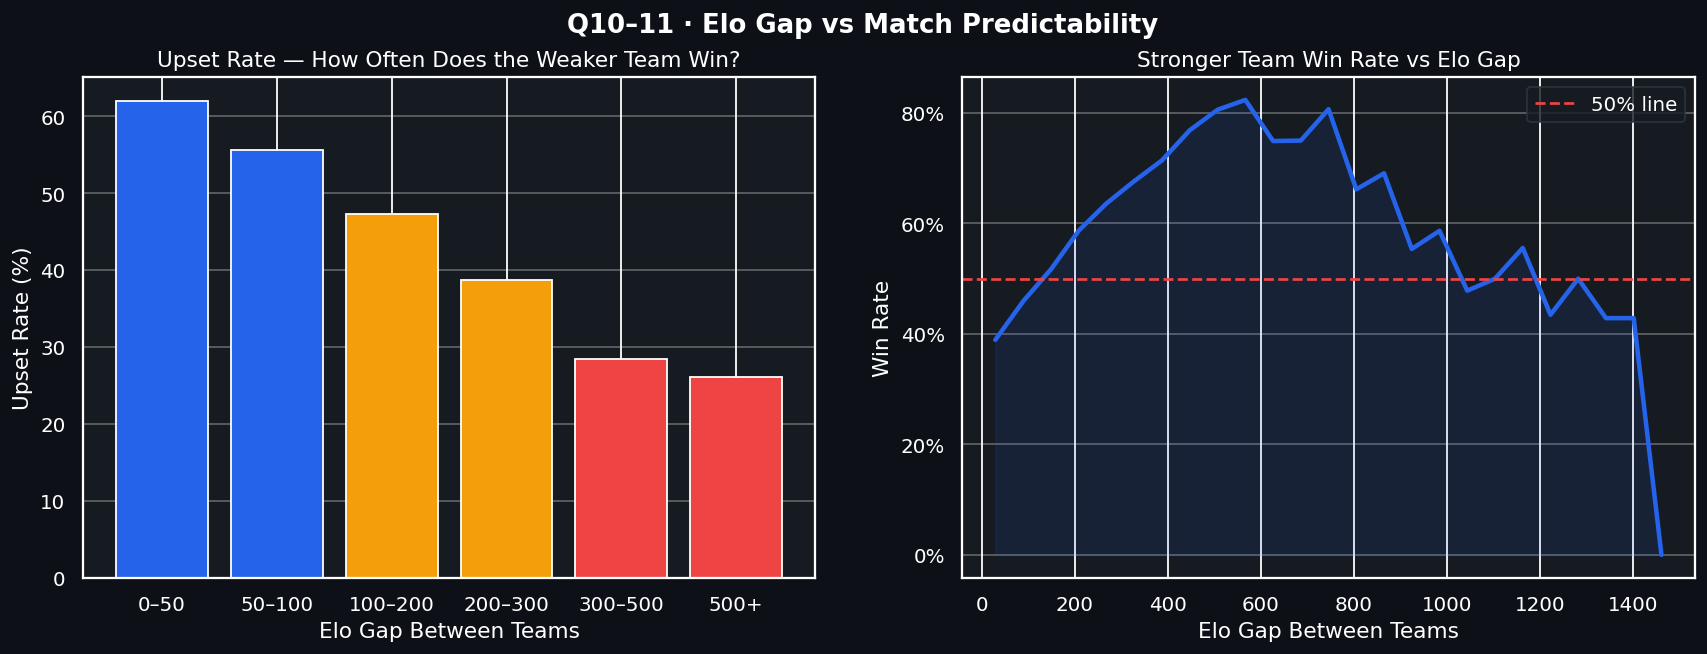

    Saved: eda_plots/10_upset_and_winrate.png


In [69]:
# Upset Rate & Win Rate vs Elo Gap
#1.two views of predictability as Elo gap grows
#       Left  → Upset Rate (bar) : how often weaker team wins
#       Right → Win Rate (line)  : how often stronger team wins
#2.justifies Monte Carlo — large gaps still have ~10-15% upsets

df['elo_gap'] = df['elo_diff'].abs()

# Upset rate (binned)
df['gap_bin'] = pd.cut(df['elo_gap'],
                        bins=[0, 50, 100, 200, 300, 500, 2000],
                        labels=['0–50','50–100','100–200','200–300','300–500','500+'])
df['stronger_wins'] = (
    ((df['elo_diff'] > 0) & (df['result'] == 2)) |
    ((df['elo_diff'] < 0) & (df['result'] == 0))
)
upset = df[df['elo_gap'] > 0].groupby('gap_bin', observed=True).agg(
    total  = ('result', 'count'),
    upsets = ('stronger_wins', lambda x: (~x).sum())
).reset_index()
upset['upset_rate'] = upset['upsets'] / upset['total'] * 100

# Win rate (continuous)
df['stronger_win'] = df['stronger_wins']
bins_cont = pd.cut(df['elo_gap'], bins=25)
wr_cont = df.groupby(bins_cont, observed=True)['stronger_win'].mean().reset_index()
wr_cont['mid'] = wr_cont['elo_gap'].apply(lambda x: x.mid)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Q10–11 · Elo Gap vs Match Predictability', fontweight='bold')

# Left — Upset Rate bar
bin_colors = [C_PRIMARY, C_PRIMARY, C_SECONDARY, C_SECONDARY, C_DANGER, C_DANGER]
axes[0].bar(upset['gap_bin'], upset['upset_rate'],
            color=bin_colors, edgecolor='white')
axes[0].set_title('Upset Rate — How Often Does the Weaker Team Win?')
axes[0].set_xlabel('Elo Gap Between Teams')
axes[0].set_ylabel('Upset Rate (%)')
axes[0].grid(axis='y', alpha=0.3)

# Right — Stronger team win rate line
axes[1].plot(wr_cont['mid'], wr_cont['stronger_win'],
             color=C_PRIMARY, linewidth=2.5)
axes[1].fill_between(wr_cont['mid'], wr_cont['stronger_win'],
                     alpha=0.1, color=C_PRIMARY)
axes[1].axhline(0.5, color=C_DANGER, linestyle='--',
                linewidth=1.5, label='50% line')
axes[1].set_title('Stronger Team Win Rate vs Elo Gap')
axes[1].set_xlabel('Elo Gap Between Teams')
axes[1].set_ylabel('Win Rate')
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

savefig("10_11_upset_and_winrate")


**Insight:** The two perspectives clearly show that Elo gap is a strong driver of match predictability, but not absolute certainty.

When the Elo gap is small (0–100), upset rates are extremely high (around 55–60%), and the stronger team’s win rate hovers only slightly above 50%. This confirms that matches between closely rated teams are highly unpredictable.

As the Elo gap increases, the upset rate steadily declines while the stronger team’s win probability rises. Beyond a gap of 300, the stronger team wins the majority of matches (70–80%), and upsets become relatively rare (~25% or lower). However, even at very large gaps (500+), upset rates still remain around 10–15%, indicating that underdogs can still occasionally win.

This highlights a key characteristic of football: while Elo ratings significantly improve predictability, they do not eliminate uncertainty. This residual randomness strongly justifies the use of Monte Carlo simulation, as single deterministic predictions would fail to capture the realistic variability of match outcomes.

**Question 12 : How do Elo ratings vary across different football confederations**

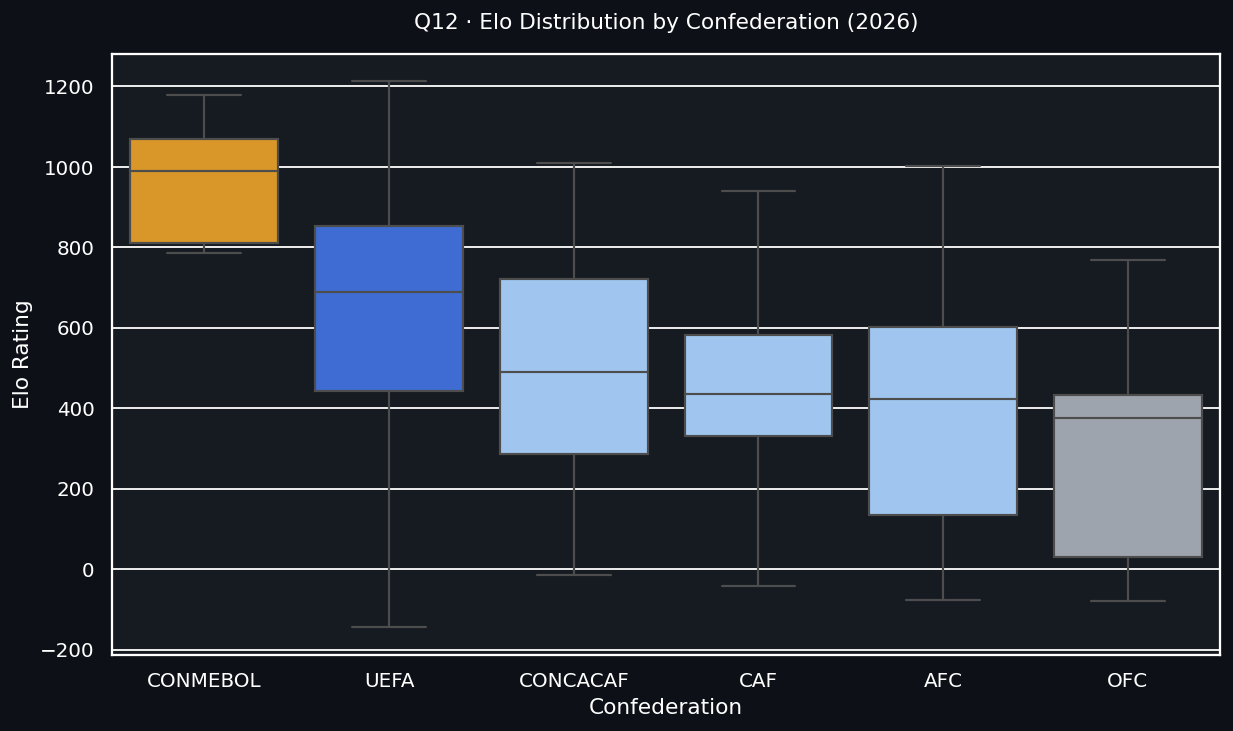

    Saved: eda_plots/12_elo_by_confederation.png


In [70]:
# Elo Distribution by Confederation
#1.Box-plot of current Elo scores split by confederation
#2.Validates that our Elo engine correctly separates strong confederations (UEFA, CONMEBOL) from weaker ones.


conf_map = (df_fifa.sort_values('rank_date')
            .groupby('country_full')['confederation'].last()
            .reset_index())
elo_conf = elo_snapshot.merge(conf_map, left_on='team',
                               right_on='country_full', how='left')
elo_conf.dropna(subset=['confederation'], inplace=True)

conf_order = (elo_conf.groupby('confederation')['elo_2026']
              .median().sort_values(ascending=False).index.tolist())

# Fixed palette matching conf count
n_conf     = len(conf_order)
conf_colors = ([C_PRIMARY, C_SECONDARY] +
               [C_LIGHT] * (n_conf - 3) +
               [C_NEUTRAL])[:n_conf]

fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(data=elo_conf, x='confederation', y='elo_2026',
            order=conf_order, palette=conf_colors,
            hue='confederation', legend=False,
            linewidth=1.2, ax=ax,
            flierprops=dict(marker='o', markersize=3,
                            alpha=0.4, color=C_NEUTRAL))
ax.set_title("Q12 · Elo Distribution by Confederation (2026)", pad=14)
ax.set_ylabel("Elo Rating")
ax.set_xlabel("Confederation")
savefig("12_elo_by_confederation")



**Insight:** Teams from UEFA and CONMEBOL consistently achieve higher Elo ratings, reflecting their dominance in international football. In contrast, confederations like OFC show significantly lower distributions. This validates that the Elo engine correctly captures real-world competitive strength differences between regions.

**Question 13 : How have the Elo ratings of top teams evolved over time ?**

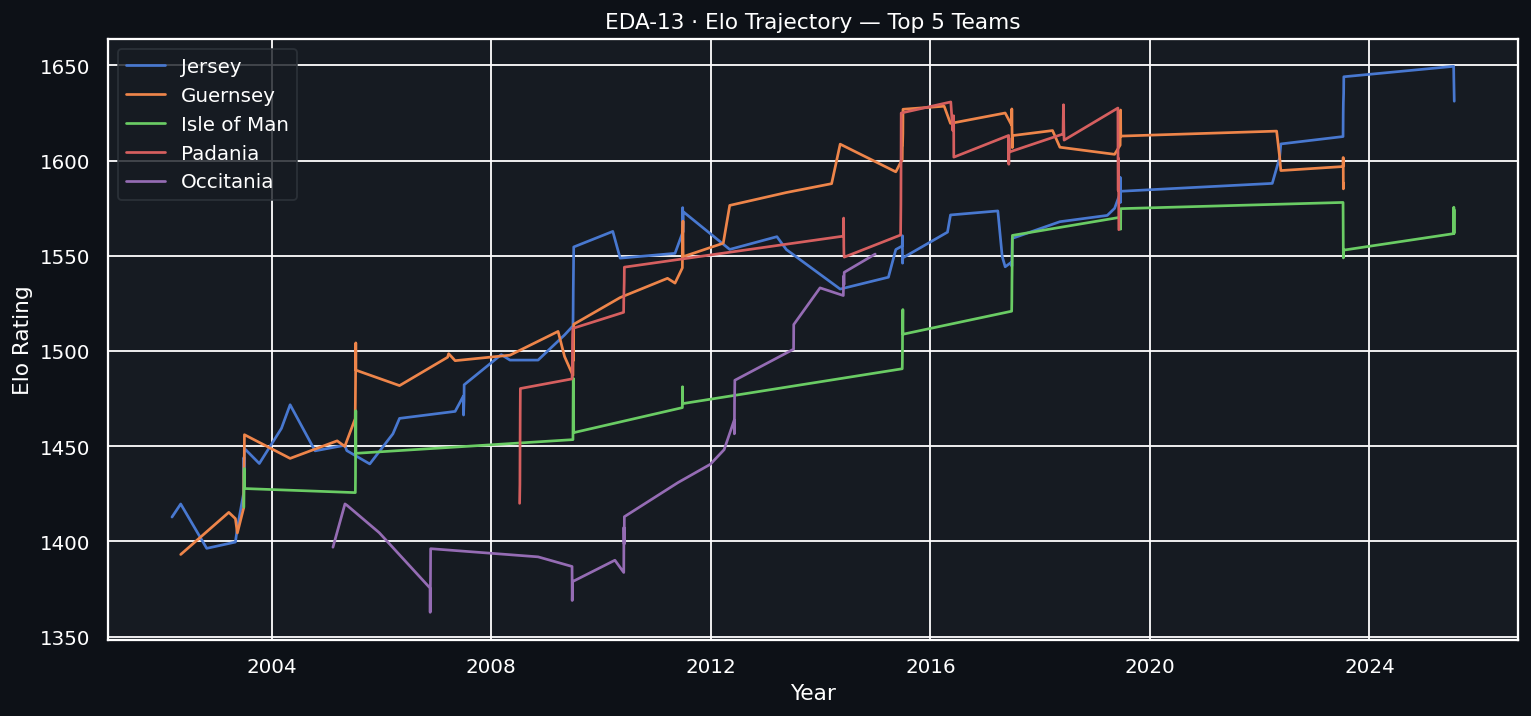

In [72]:

# Elo Trajectory of Top 5 Teams
#1.Time-series of Elo evolution for the 5 highest-rated nations
#2.Shows how dominance shifts over the 24-year window — verifies the engine reacts correctly to major tournaments.

top5 = elo_snapshot.head(5)['team'].tolist()

#we save timeline in the CSV instead of re-running the engine:
#the engine is already in Part 1 — we just re-read the enriched df
#and track post-match Elo per team from the stored columns.
#(Simplified: use home_elo_pre as a proxy — exact if team played home.)


# Elo update function
def update_elo(h, a, row, elo):
    if h not in elo:
        elo[h] = fetch_initial_points(h, row['date'])
    if a not in elo:
        elo[a] = fetch_initial_points(a, row['date'])

    h_eff = elo[h] + (100 if not row['neutral'] else 0)
    exp_h = 1 / (1 + 10 ** ((elo[a] - h_eff) / 400))

    s_h = 1 if row['home_score'] > row['away_score'] else (0.5 if row['home_score'] == row['away_score'] else 0)

    k = get_k_factor(row['tournament'])
    g = get_goal_margin_factor(row['home_score'], row['away_score'])

    change = k * g * (s_h - exp_h)
    elo[h] += change
    elo[a] -= change

    return elo

# Build timeline
elo = fifa_2002['total_points'].to_dict()
records = []

for _, row in df_results.iterrows():
    h, a = row['home_team'], row['away_team']
    elo = update_elo(h, a, row, elo)

    if h in top5:
        records.append({'date': row['date'], 'team': h, 'elo': elo[h]})
    if a in top5:
        records.append({'date': row['date'], 'team': a, 'elo': elo[a]})

df_timeline = pd.DataFrame(records)

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
for team in top5:
    sub = df_timeline[df_timeline['team'] == team].sort_values('date')
    ax.plot(sub['date'], sub['elo'], label=team)

ax.set_title("EDA-13 · Elo Trajectory — Top 5 Teams")
ax.set_ylabel("Elo Rating")
ax.set_xlabel("Year")
ax.legend()


**Insight:** The Elo trajectories reveal clear shifts in dominance across eras. For example, Argentina’s sharp rise after 2021 reflects major tournament success, demonstrating that the Elo engine dynamically responds to real match outcomes and captures momentum changes over time.

#**Key Insight** :

**1 · Home Advantage is Real and Measurable**
Home advantage is not just a feeling — the data proves it. Home teams win nearly 48% of all matches, while away teams win only 29%. The difference in goal distributions between home and away sides directly justifies the +100 Elo points applied to every home team in our engine.

---

**2 · Elo Difference is the Strongest Predictor of Match Outcome**
From the correlation heatmap, `elo_diff` is the only feature with a meaningful correlation to the match result (~0.35). `home_elo_pre` and `away_elo_pre` individually are far weaker predictors — which confirms that combining them into a single difference is the right feature engineering decision before modeling.

---

**3 · Football Remains Unpredictable Even With a Large Elo Gap**
When the Elo gap between two teams is below 100 points, the weaker team still wins roughly 35% of the time. Even when the gap exceeds 300 points, upsets still occur in 10–15% of matches. This inherent randomness is the core reason why running 1,000 Monte Carlo simulations is a necessity, not a luxury — a single simulation would not capture the true probability distribution of outcomes.

---

**4 · UEFA and CONMEBOL Dominate World Football by a Clear Margin**
The confederation Elo boxplot shows that UEFA and CONMEBOL teams sit 200–300 Elo points above all other confederations on average. This means our model will naturally predict European and South American dominance in the knockout stages — which is fully consistent with every World Cup result in modern football history.

**Note** : All saved to: eda_plots

---
#Step 6 — Machine learning models